# Modelisation - Home Credit default risk 

* Prédire la probabilité de défault d'un client qui sollicite un crédit bancaire, afin de décider de l'octroi ou non du crédit demandé

## Imports Librairies

In [27]:
# --- Base ---
import numpy as np
import pandas as pd
from pathlib import Path 

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sélection de modèles & validation ---
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score, cross_validate, cross_val_predict

# --- Prétraitement ---
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, LabelEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

# --- Modèles de classification (scikit-learn) ---
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# --- Modèles de régression (scikit-learn) ---
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# --- (Optionnels) XGBoost / LightGBM / CatBoost : import si installés ---
try:
    from xgboost import XGBClassifier, XGBRegressor
except Exception:
    XGBClassifier = XGBRegressor = None
try:
    from lightgbm import LGBMClassifier, LGBMRegressor
except Exception:
    LGBMClassifier = LGBMRegressor = None
try:
    from catboost import CatBoostClassifier, CatBoostRegressor
except Exception:
    CatBoostClassifier = CatBoostRegressor = None

# --- Métriques : classification & régression ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, classification_report,
    r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
)

# --- Importance des features & interprétabilité ---
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay  # PDP/ICE
# SHAP (si installé) : importance globale & locale
try:
    import shap
except Exception:
    shap = None

from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
precision_score, recall_score,roc_auc_score,
ConfusionMatrixDisplay, classification_report,
precision_recall_curve, auc, roc_curve)
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import optuna
from optuna.integration import OptunaSearchCV
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from creditscoring.utils import save_outputs
import joblib
import mlflow
from mlflow.models.signature import infer_signature


## CHARGEMENT DES DONNEES

In [3]:
BASE_DIR = Path.cwd().parent
data_path = BASE_DIR / "data" / "processed_data"

data_train = pd.read_csv(data_path / "train_clean.csv")
data_test = pd.read_csv(data_path / "test_clean.csv")

print("Les données d'entrainement ont été chargé :", data_train.shape)
print("Les données de test ont été chargé :",data_test.shape)

Les données d'entrainement ont été chargé : (307511, 149)
Les données de test ont été chargé : (48744, 149)


In [4]:
data_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_DAYS_ENTRY_DIFF_MEAN,INST_LATE_PAYMENT_RATE,INST_SHORT_PAYMENT_RATE,INST_COUNT,INST_LATE_RATE_RECENT,POS_MONTHS_COUNT,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_DPD_RATE,POS_CNT_INSTALMENT_MEAN
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,20.421053,1.000000,0.000000,19.0,1.000000,19.0,0.0,0.0,0.0,24.000000
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,7.160000,1.000000,0.000000,25.0,NaN,28.0,0.0,0.0,0.0,10.107143
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,7.666667,1.000000,0.000000,3.0,NaN,4.0,0.0,0.0,0.0,3.750000
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,19.375000,1.000000,0.000000,16.0,1.000000,21.0,0.0,0.0,0.0,12.000000
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,3.636364,0.621212,0.090909,66.0,0.846154,66.0,0.0,0.0,0.0,15.333333


In [5]:
data_test.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_DAYS_ENTRY_DIFF_MEAN,INST_LATE_PAYMENT_RATE,INST_SHORT_PAYMENT_RATE,INST_COUNT,INST_LATE_RATE_RECENT,POS_MONTHS_COUNT,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_DPD_RATE,POS_CNT_INSTALMENT_MEAN
0,100001,NaN,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,7.285714,0.571429,0.000000,7.0,NaN,9.0,0.777778,7.0,0.111111,4.000000
1,100005,NaN,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,23.555556,0.888889,0.000000,9.0,NaN,11.0,0.000000,0.0,0.000000,11.700000
2,100013,NaN,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,5.180645,0.316129,0.129032,155.0,0.333333,36.0,0.944444,18.0,0.055556,21.388889
3,100028,NaN,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,3.000000,0.486726,0.176991,113.0,0.263158,31.0,0.000000,0.0,0.000000,20.354839
4,100038,NaN,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,12.250000,1.000000,0.000000,12.0,NaN,13.0,0.000000,0.0,0.000000,12.000000


## MODELISATION

In [6]:
# --------------------------------------------------
# Séparation features / target
# On prépare les données de train / test ( test en entrainement ) / test_final : prédictions
# --------------------------------------------------
id_col = 'SK_ID_CURR'
target_col = 'TARGET'

X = data_train.drop(columns=[target_col, id_col])
y = data_train[target_col]

X_test_final = data_test.drop(columns=[target_col, id_col], errors='ignore')
test_ids = data_test[id_col]

In [7]:
print(X.dtypes.value_counts())

float64    94
int64      38
object     15
Name: count, dtype: int64


In [8]:
# --------------------------------------------------
# Colonnes numériques / catégorielles
# --------------------------------------------------
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
print(len(categorical_cols))  # devrait être 15
print(len(numerical_cols))      # devrait être 124

15
132


In [9]:
# --------------------------------------------------
# Pipelines de preprocessing
# --------------------------------------------------
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numerical_cols),
        ("cat", cat_pipe, categorical_cols),
    ],
    remainder="drop"
)

In [10]:
# --------------------------------------------------
# Modèles à comparer
# --------------------------------------------------
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=11,
        n_jobs=-1
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=11,
        n_jobs=-1
    ),
    
    "LightGBM": LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        verbose=-1,
        random_state=11,
        n_jobs=-1
    )
}

In [11]:
# --------------------------------------------------
# Validation croisée
# --------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    results.append({
        "model": name,
        "auc_mean": scores.mean(),
        "auc_std": scores.std()
    })

results_df = pd.DataFrame(results).sort_values(by="auc_mean", ascending=False)
print("\nClassement final :")
print(results_df)


Classement final :
          model  auc_mean   auc_std
2      LightGBM  0.782040  0.003136
1       XGBoost  0.781003  0.002947
0  RandomForest  0.755087  0.002569


Les résultats en CV montrent que LGBM est le plus performant, suivi de très près par XGBOOST. Nous allons tuner les hyperparamètres pour tenter d'améliorer encore plus la performance.

J'ai fait une modélisation sans preprocessing pour LGBM et XGBOOST en utilisant les paramètres par défaut de ces 2 modèles, mais les résultats obtenus sans légèrement moins bons. Je laisse donc le preprocessing.

## TUNING DE LGBM : 

In [12]:
#=====================================================
# Tuning Hyperparamètres LGBM - Optuna
#=====================================================

cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=11)

def objective(trial):
    params = {
        "model__n_estimators":      trial.suggest_int("n_estimators", 1200, 2500),
        "model__learning_rate":     trial.suggest_float("learning_rate", 0.015, 0.04, log=True),
        "model__num_leaves":        trial.suggest_int("num_leaves", 15, 40),
        "model__max_depth":         trial.suggest_int("max_depth", 6, 10),
        "model__min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "model__subsample":         trial.suggest_float("subsample", 0.85, 1.0),
        "model__colsample_bytree":  trial.suggest_float("colsample_bytree", 0.55, 0.75),
        "model__reg_alpha":         trial.suggest_float("reg_alpha", 1.0, 5.0, log=True),
        "model__reg_lambda":        trial.suggest_float("reg_lambda", 0.1, 1.0, log=True),
        "model__class_weight":      None,
    }
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(random_state=11, n_jobs=-1, verbose=-1))
    ])
    pipe.set_params(**params)
    scores = cross_val_score(pipe, X, y, cv=cv_fast, scoring="roc_auc", n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=11))

# Point de départ : meilleurs params connus
study.enqueue_trial({
    "n_estimators": 1462,
    "learning_rate": 0.026,
    "num_leaves": 23,
    "max_depth": 7,
    "min_child_samples": 39,
    "subsample": 0.908,
    "colsample_bytree": 0.717,
    "reg_alpha": 4.017,
    "reg_lambda": 0.386,
})

study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"Best AUC  : {study.best_value:.6f}")
print(f"Best params : {study.best_params}")

Best trial: 19. Best value: 0.784722: 100%|██████████| 20/20 [18:55<00:00, 56.80s/it]

Best AUC  : 0.784722
Best params : {'n_estimators': 1783, 'learning_rate': 0.020518072406393018, 'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 14, 'subsample': 0.8762921551375087, 'colsample_bytree': 0.5549599329611689, 'reg_alpha': 3.7882224870575327, 'reg_lambda': 0.10396455669780998}


In [13]:
# Validation finale en 5 folds avec les meilleurs params
best_params = {f"model__{k}": v for k, v in study.best_params.items()}

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(random_state=11, n_jobs=-1, verbose=-1))
])
best_pipe.set_params(**best_params)

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
scores = cross_val_score(best_pipe, X, y, cv=cv_5, scoring="roc_auc", n_jobs=-1)
print(f"AUC 5-folds final : {scores.mean():.6f} ± {scores.std():.6f}")

# Entraînement sur tout le dataset
best_pipe.fit(X, y)


AUC 5-folds final : 0.786417 ± 0.002961


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Feature Importance : 

=== Top 20 features (importance native) ===
CREDIT_TERM                   2178
DAYS_BIRTH                    1449
EXT_SOURCE_MEAN               1275
PREV_ANNUITY_MEAN             1099
EXT_SOURCE_2                  1094
POS_CNT_INSTALMENT_MEAN       1087
DAYS_ID_PUBLISH               1072
DAYS_EMPLOYED                 1066
AMT_ANNUITY                   1057
PREV_APP_CREDIT_RATIO_MEAN    1030
DAYS_REGISTRATION             1010
EXT_SOURCE_3                   976
DEBT_CREDIT_RATIO_max          950
ANNUITY_INCOME_RATIO           933
INST_COUNT                     928
GOODS_CREDIT_RATIO             924
EXT_SOURCE_1                   921
PREV_DAYS_DECISION_MIN         914
DAYS_CREDIT_max                882
POS_MONTHS_COUNT               875
dtype: int32


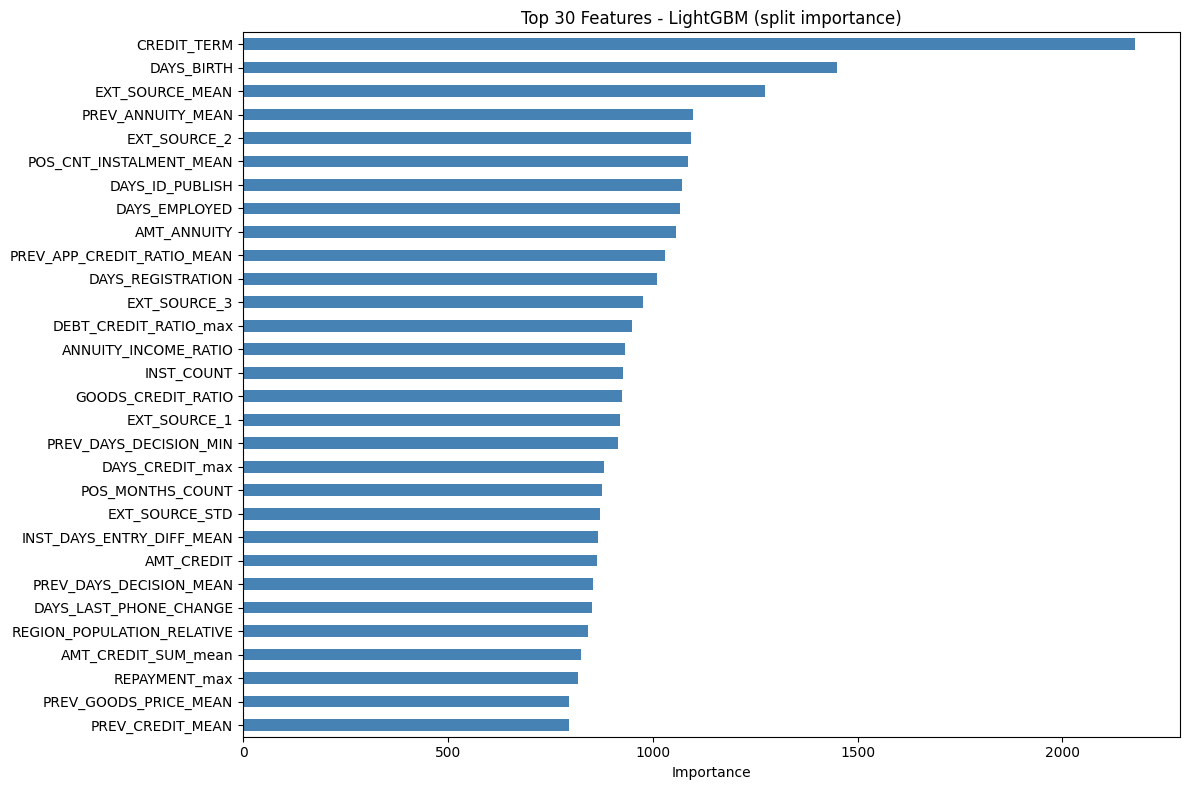


15 features à importance nulle : ['FLAG_MOBIL', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'EMERGENCYSTATE_MODE']


In [ ]:
# ==================================================
# Feature Importance
# ==================================================

# --- Récupérer les noms de features après preprocessing ---
num_feature_names = numerical_cols
cat_feature_names = categorical_cols
all_feature_names = num_feature_names + cat_feature_names

# --- Importance native LGBM (split-based) ---
lgbm_model = best_pipe.named_steps['model']
importances = pd.Series(
    lgbm_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

print("=== Top 20 features (importance native) ===")
print(importances.head(20))

# Visualisation Top 30
plt.figure(figsize=(12, 8))
importances.head(30).sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 30 Features - LightGBM (split importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Features à importance nulle
zero_imp = importances[importances == 0].index.tolist()
print(f"\n{len(zero_imp)} features à importance nulle : {zero_imp}")

Interprétation de la Feature importance : 

* CREDIT_TERM (La plus importante) : 
Plus la durée est longue, plus risque de défaut augmente

* DAYS_BIRTH
Plus clients sont jeunes  plus le risque augmente. (moins de stabilité financière pour les jeunes)

* EXT_SOURCE_MEAN
Moyenne des 3 scores externes (EXT_SOURCE_1,2,3) cad que l'agrégation des agences de crédit externes est très prédictive.

* PREV_ANNUITY_MEAN 
Plus la moyenne des mensualités des crédits précédents est élévée, plus le risque de défaut est élevé aussi.

* EXT_SOURCE_2
Il s'agit du sscore externe n°2 (probablement d'une banque). ce score très fiable pour séparer bons/mauvais payeurs.



/Users/fatiza/Library/Caches/pypoetry/virtualenvs/creditscoring-XOSM21zS-py3.12/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


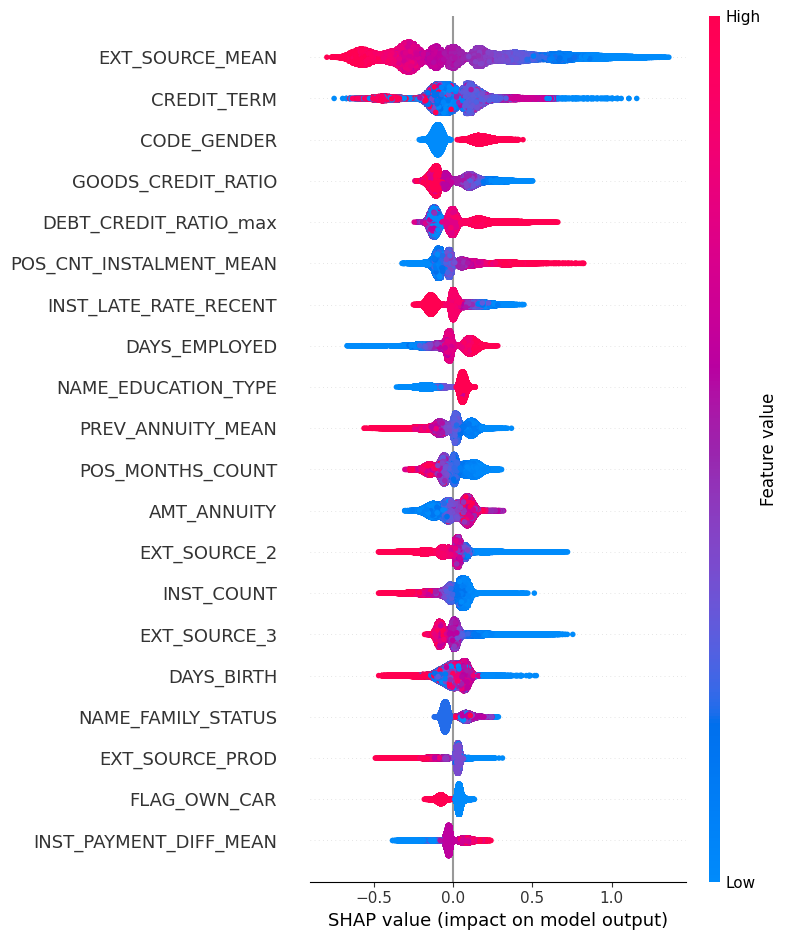

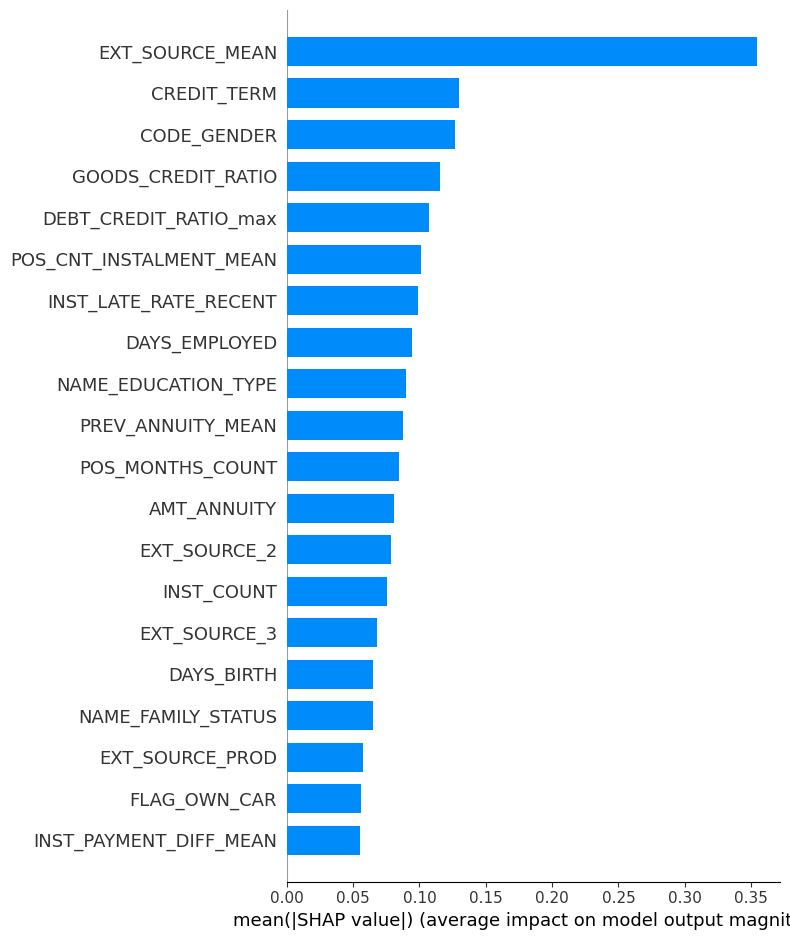

In [29]:
# --- SHAP values (interprétabilité locale et globale) ---

# Préprocesser X pour SHAP
X_processed = best_pipe.named_steps['preprocessor'].transform(X)
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

# Explainer LGBM natif (rapide)
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_processed_df)

# Si shap_values est une liste (binaire), prendre l'index 1 (classe positive)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# Summary plot global
plt.figure()
shap.summary_plot(sv, X_processed_df, max_display=20, show=True)

# Bar plot (importance agrégée)
plt.figure()
shap.summary_plot(sv, X_processed_df, plot_type="bar", max_display=20, show=True)

L'étude de feature importance SHAP montre que globalement les features importantes sont similaires entre les deux méthodes, avec des différences de Ranking par méthode.

PR  AUC (OOF) : 0.2795
ROC AUC (OOF) : 0.7864


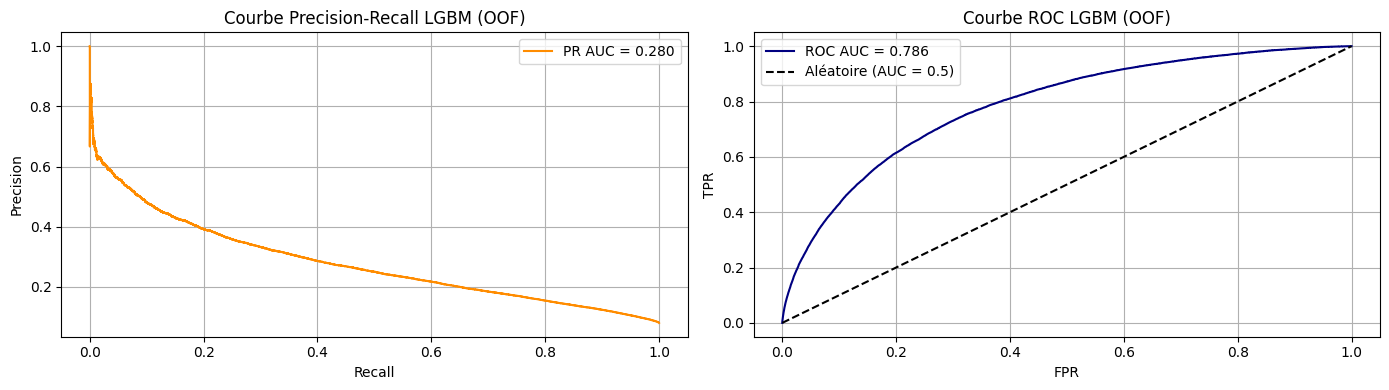

In [16]:
# ==================================================
# Évaluation OOF — sans data leakage
# ==================================================

y_proba_oof = cross_val_predict(
    best_pipe, X, y,
    cv=cv_5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# --- Courbe Precision-Recall ---
prec_, rec_, thresholds_pr = precision_recall_curve(y, y_proba_oof)
pr_auc_ = auc(rec_, prec_)

# --- Courbe ROC ---
fpr_, tpr_, thresholds_roc = roc_curve(y, y_proba_oof)
roc_auc_ = auc(fpr_, tpr_)

print(f"PR  AUC (OOF) : {pr_auc_:.4f}")
print(f"ROC AUC (OOF) : {roc_auc_:.4f}")  # doit être ~0.784

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(rec_, prec_, label=f"PR AUC = {pr_auc_:.3f}", color='darkorange')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall LGBM (OOF)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fpr_, tpr_, label=f"ROC AUC = {roc_auc_:.3f}", color='navy')
plt.plot([0,1], [0,1], "k--", label="Aléatoire (AUC = 0.5)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Courbe ROC LGBM (OOF)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**ROC AUC = 0.786** très bon pouvoir discriminant du modèle.
Notre modèle distingue bien un client défaillant d’un client non-défaillant.

**PR AUC = 0.279** : c'est faible, mais cela est normal car le jeu de données est déséquilibré.
Pour les besoins métier, nous nous focalisons plus sur la métrique ROC AUC qui est plus importante dans notre cas.


In [17]:
# ==================================================
# Table de déciles — pilotage métier
# ==================================================

decile_df = pd.DataFrame({'proba': y_proba_oof, 'target': y})
decile_df['decile'] = pd.qcut(decile_df['proba'], q=10, labels=False, duplicates='drop')
decile_df['decile'] = 9 - decile_df['decile']  # décile 0 = plus risqué

table = decile_df.groupby('decile').agg(
    nb_clients  = ('target', 'count'),
    nb_defauts  = ('target', 'sum'),
    proba_moy   = ('proba',  'mean')
).assign(
    taux_defaut         = lambda d: (d['nb_defauts'] / d['nb_clients'] * 100).round(2),
    pct_defauts_captures= lambda d: (d['nb_defauts'].cumsum() / d['nb_defauts'].sum() * 100).round(2)
)

print("=== Table de déciles ===")
print(table)

=== Table de déciles ===
        nb_clients  nb_defauts  proba_moy  taux_defaut  pct_defauts_captures
decile                                                                      
0            30751      9219.0   0.301926        29.98                 37.14
1            30751      4845.0   0.149379        15.76                 56.65
2            30751      3164.0   0.099356        10.29                 69.40
3            30751      2327.0   0.071714         7.57                 78.77
4            30751      1658.0   0.053885         5.39                 85.45
5            30751      1297.0   0.041206         4.22                 90.67
6            30751       886.0   0.031524         2.88                 94.24
7            30751       671.0   0.023697         2.18                 96.95
8            30751       495.0   0.016867         1.61                 98.94
9            30752       263.0   0.009629         0.86                100.00


Cette table des déciles est le moyen le plus utile pour l'équipe métier pour faciliter la prise de décision. 
Exemple de stratégie de refus : refuser les déciles de 0 à 2 ( soit 30% des clients ) permet d'éliminer 69,4% des défauts. 

In [ ]:
#Générer les prédictions
y_pred_proba = best_pipe.predict_proba(X_test_final)[:, 1]

proba_Xtest = pd.DataFrame({
    'SK_ID_CURR': test_ids,
    'TARGET': y_pred_proba
    })

save_outputs( proba_Xtest, "proba_Xtest.csv")
print(f"probabilités sauvegardées ")

probabilités sauvegardée 


In [20]:
# Enregister le meilleur model 
model_path = BASE_DIR / "models" / "best_pipe_lgbm.pkl"
model_path.parent.mkdir(exist_ok=True)  # crée le dossier models s'il n'existe pas

joblib.dump(best_pipe, model_path)
print(f"Modèle sauvegardé dans : {model_path} ")

Modèle sauvegardé dans : /Users/fatiza/Documents/DATA SCIENTIST/CreditScoring/creditscoring/models/best_pipe_lgbm.pkl 


In [30]:
# ==================================================
# MLflow Logging
# ==================================================


# Générer signature et exemple
X_sample = X.iloc[:5]
X_sample_processed = best_pipe.named_steps['preprocessor'].transform(X_sample)
y_sample_pred = best_pipe.predict_proba(X_sample)[:, 1]

signature = infer_signature(X_sample, y_sample_pred)

mlflow.set_experiment("Projet- Home Credit Default Risk")
mlflow.set_tracking_uri("http://127.0.0.1:5000")


if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="lgbm_optuna_tuned"):

    mlflow.log_params(study.best_params)
    mlflow.log_metric("auc_cv_mean", scores.mean())
    mlflow.log_metric("auc_cv_std",  scores.std())
    mlflow.log_metric("auc_oof",     roc_auc_)
    mlflow.log_metric("pr_auc_oof",  pr_auc_)

    for feat, imp in importances.head(10).items():
        mlflow.log_metric(f"importance_{feat}", float(imp))

    # Modèle avec signature et exemple 
    
    mlflow.sklearn.log_model(
        best_pipe,
        artifact_path="model",
        signature=signature,
        input_example=X_sample
    )

    mlflow.log_artifact(str(BASE_DIR / "data" / "predictions" / "proba_Xtest.csv"))
    mlflow.log_artifact(str(model_path))
    table.to_csv("decile_table.csv", index=True)
    mlflow.log_artifact("decile_table.csv")

    fig, ax = plt.subplots(figsize=(10, 7))
    importances.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title("Top 20 Features - LightGBM")
    mlflow.log_figure(fig, "feature_importance_top20.png")
    plt.close(fig)

    print(f"Run MLflow enregistré ✅")
    print(f"AUC CV   : {scores.mean():.6f} ± {scores.std():.6f}")
    print(f"AUC OOF  : {roc_auc_:.6f}")

/Users/fatiza/Library/Caches/pypoetry/virtualenvs/creditscoring-XOSM21zS-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Run MLflow enregistré ✅
AUC CV   : 0.786417 ± 0.002961
AUC OOF  : 0.786409
🏃 View run lgbm_optuna_tuned at: http://127.0.0.1:5000/#/experiments/226994350639478882/runs/a694f07b89134314b7eaacc3609cc86a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/226994350639478882
